In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional, Tuple, Dict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


In [2]:
def beam_centroid_sigma(cloud: torch.Tensor, eps: float = 1e-12) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    cloud: [B, Np, 6]
    returns:
      centroid: [B, 6]
      sigma:    [B, 6] (std dev)
    """
    centroid = cloud.mean(dim=1)
    var = (cloud - centroid[:, None, :]).pow(2).mean(dim=1)
    sigma = torch.sqrt(var + eps)
    return centroid, sigma


In [3]:
PAIR_INDEX = [
    (0, 1), (0, 2), (0, 3), (0, 4), (0, 5),
    (1, 2), (1, 3), (1, 4), (1, 5),
    (2, 3), (2, 4), (2, 5),
    (3, 4), (3, 5),
    (4, 5),
]

def _soft_hist2d(
    x: torch.Tensor,
    y: torch.Tensor,
    x_edges: torch.Tensor,
    y_edges: torch.Tensor,
) -> torch.Tensor:
    """
    Differentiability is not required for histogramming (your pipeline is simulation-based),
    so we implement a fast non-differentiable binning via torch.bucketize.
    x, y: [B, Np]
    edges: [nbins+1]
    returns hist: [B, nbins, nbins]
    """
    B, Np = x.shape
    nb = x_edges.numel() - 1

    # bin indices in [0, nb-1], clamp out-of-range
    ix = torch.bucketize(x, x_edges) - 1
    iy = torch.bucketize(y, y_edges) - 1
    ix = ix.clamp(0, nb - 1)
    iy = iy.clamp(0, nb - 1)

    # flatten 2D bins -> 1D
    flat = ix * nb + iy  # [B, Np]
    hist = torch.zeros(B, nb * nb, device=x.device, dtype=torch.float32)
    ones = torch.ones_like(flat, dtype=torch.float32)
    hist.scatter_add_(dim=1, index=flat, src=ones)
    hist = hist.view(B, nb, nb)
    return hist


def cloud_to_pairwise_hists(
    cloud: torch.Tensor,
    nbins: int = 64,
    clip_k: float = 5.0,
    eps: float = 1e-12,
) -> torch.Tensor:
    """
    Convert 6D cloud [B,Np,6] -> [B,15,64,64] hist tensor.
    Range per coordinate is centered at centroid with +/- clip_k * sigma.
    Histogram is normalized by particle count.
    """
    B, Np, D = cloud.shape
    assert D == 6, f"Expected 6D, got {D}"

    centroid, sigma = beam_centroid_sigma(cloud, eps=eps)  # [B,6]

    # Precompute edges per coord, per batch item.
    # For simplicity we loop over coords to build edges [B, nbins+1].
    edges = []
    for d in range(6):
        lo = centroid[:, d] - clip_k * sigma[:, d]
        hi = centroid[:, d] + clip_k * sigma[:, d]
        # Handle near-zero sigma -> make a small interval
        hi = torch.where((hi - lo) < 1e-9, lo + 1e-9, hi)

        # linspace per batch item (vectorized)
        t = torch.linspace(0.0, 1.0, nbins + 1, device=cloud.device, dtype=torch.float32)[None, :]
        ed = lo[:, None].to(torch.float32) * (1 - t) + hi[:, None].to(torch.float32) * t
        edges.append(ed)
    # edges[d]: [B, nbins+1]

    out = []
    for (i, j) in PAIR_INDEX:
        xi = cloud[:, :, i].to(torch.float32)
        yj = cloud[:, :, j].to(torch.float32)

        # bucketize needs 1D edges; we must do per-batch item.
        # Loop over batch for correctness; for speed you can pre-bin offline.
        h = torch.zeros(B, nbins, nbins, device=cloud.device, dtype=torch.float32)
        for b in range(B):
            hb = _soft_hist2d(xi[b:b+1], yj[b:b+1], edges[i][b], edges[j][b])  # [1,nb,nb]
            h[b] = hb[0]
        h = h / (float(Np) + eps)
        out.append(h)

    return torch.stack(out, dim=1)  # [B,15,nb,nb]


In [4]:
class PaperDataset(Dataset):
    def __init__(self, data: dict, split: str = "train"):
        self.Xh = data["X_hist"]      # [Ns,15,64,64]
        self.Yh = data["Y_hist"]
        self.aux_in = data["aux_in"]  # [Ns,12]
        self.MU = data["MU_feat"]     # use preprocessed MU directly

        self.idx = data[split].astype(np.int64) if split in data else np.arange(self.Xh.shape[0])

    def __len__(self): return len(self.idx)

    def __getitem__(self, i: int):
        j = int(self.idx[i])
        return (
            torch.from_numpy(self.Xh[j]).float(),
            torch.from_numpy(self.Yh[j]).float(),
            torch.from_numpy(self.aux_in[j]).float(),
            torch.from_numpy(self.MU[j]).float(),
        )

In [15]:
class ConvBlock(nn.Module):
    def __init__(self, c_in: int, c_out: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, stride=2, padding=1),  # /2
            nn.GroupNorm(8, c_out),
            nn.GELU(),
            nn.Conv2d(c_out, c_out, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(8, c_out),
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)


class UpBlock(nn.Module):
    def __init__(self, c_in: int, c_out: int):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(8, c_out),
            nn.GELU(),
            nn.Conv2d(c_out, c_out, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(8, c_out),
            nn.GELU(),
        )

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2.0, mode="bilinear", align_corners=False)
        return self.conv(x)


class BeamVAE(nn.Module):
    def __init__(
        self,
        in_ch: int = 15,
        latent_dim: int = 256,
        aux_dim: int = 12,     # 6 sigmas + 6 centroids
        base_ch: int = 32,
    ):
        super().__init__()
        self.latent_dim = latent_dim
        self.aux_dim = aux_dim

        # Encoder: 64->32->16->8->4 spatial
        self.enc1 = ConvBlock(in_ch, base_ch)            # 64 -> 32
        self.enc2 = ConvBlock(base_ch, base_ch * 2)      # 32 -> 16
        self.enc3 = ConvBlock(base_ch * 2, base_ch * 4)  # 16 -> 8
        self.enc4 = ConvBlock(base_ch * 4, base_ch * 8)  # 8  -> 4

        # feature size after enc4 is [B, base_ch*8, 4, 4] => flatten
        self.enc_feat_dim = (base_ch * 8) * 4 * 4

        # combine flattened feature with aux(12) and optional MU if provided upstream
        self.fc = nn.Linear(self.enc_feat_dim + aux_dim, 1024)
        self.fc_mu = nn.Linear(1024, latent_dim)
        self.fc_logvar = nn.Linear(1024, latent_dim)

        # Decoder: start from z -> feature map -> upsample blocks to 64x64
        self.dec_fc = nn.Linear(latent_dim, self.enc_feat_dim)
        self.dec1 = UpBlock(base_ch * 8, base_ch * 4)   # 4 -> 8
        self.dec2 = UpBlock(base_ch * 4, base_ch * 2)   # 8 -> 16
        self.dec3 = UpBlock(base_ch * 2, base_ch)       # 16 -> 32
        self.dec4 = UpBlock(base_ch, base_ch)           # 32 -> 64
        self.dec_out = nn.Conv2d(base_ch, in_ch, kernel_size=1)

        # Auxiliary heads directly from z
        self.aux_sigma_head = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.GELU(),
            nn.Linear(256, 6),
        )
        self.aux_centroid_head = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.GELU(),
            nn.Linear(256, 6),
        )

    def encode(self, x_hist: torch.Tensor, aux: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        x_hist: [B,15,64,64]
        aux:    [B,12]  (sigmas + centroids)
        returns mu, logvar: [B,256]
        """
        h = self.enc1(x_hist)
        h = self.enc2(h)
        h = self.enc3(h)
        h = self.enc4(h)
        h = h.flatten(1)
        h = torch.cat([h, aux], dim=1)
        h = F.gelu(self.fc(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparam(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """
        Decode latent -> 15x64x64 nonnegative maps, normalized so each map sums to 1.
        This matches your target histograms (normalized by particle count).
        """
        h = self.dec_fc(z).view(z.shape[0], -1, 4, 4)
        h = self.dec1(h)
        h = self.dec2(h)
        h = self.dec3(h)
        h = self.dec4(h)

        # linear output (no sigmoid), enforce nonnegativity
        x_hat = self.dec_out(h)
        x_hat = torch.clamp(x_hat, min=0.0)

        # normalize each of the 15 maps so sum_{i,j} x_hat[c,i,j] = 1
        x_hat = x_hat / (x_hat.sum(dim=(-1, -2), keepdim=True) + 1e-12)
        return x_hat

    def forward(self, x_hist: torch.Tensor, aux: torch.Tensor) -> Dict[str, torch.Tensor]:
        mu, logvar = self.encode(x_hist, aux)
        z = self.reparam(mu, logvar)
        x_hat = self.decode(z)
        sigma_hat = self.aux_sigma_head(z)
        centroid_hat = self.aux_centroid_head(z)
        return {
            "mu": mu,
            "logvar": logvar,
            "z": z,
            "x_hat": x_hat,
            "sigma_hat": sigma_hat,
            "centroid_hat": centroid_hat,
        }


In [3]:

@dataclass
class ElementNormScales:
    L: float = 1.0
    K1: float = 10.0     # m^-2
    K2: float = 10.0     # m^-3 (you wrote 10.0 m^-3)
    phi: float = 2.0 * 3.141592653589793
    Vrf: float = 1.0     # handled by log1p, scale effectively 1
    frf: float = 1.0     # handled by log1p, scale effectively 1
    phirf: float = 2.0 * 3.141592653589793


def normalize_elem_params(p: torch.Tensor, scales: ElementNormScales) -> torch.Tensor:
    """
    p: [B,N,7] in order [L,K1,K2,phi,Vrf,frf,phirf]
    returns normalized [B,N,7]
    """
    L, K1, K2, phi, Vrf, frf, phirf = torch.unbind(p, dim=-1)
    L = L / scales.L
    K1 = K1 / scales.K1
    K2 = K2 / scales.K2
    phi = phi / scales.phi
    Vrf = torch.log1p(torch.clamp(Vrf, min=0.0))
    frf = torch.log1p(torch.clamp(frf, min=0.0))
    phirf = phirf / scales.phirf
    return torch.stack([L, K1, K2, phi, Vrf, frf, phirf], dim=-1)


class FourierPositionalEncoding(nn.Module):
    """
    Fourier features for s-position with 32 frequency pairs.
    wavelengths geometrically spaced from 1 cm to 1 km.
    """
    def __init__(self, n_freq_pairs: int = 32, wl_min: float = 1e-2, wl_max: float = 1e3):
        super().__init__()
        self.n = n_freq_pairs
        wls = torch.logspace(
            torch.log10(torch.tensor(wl_min)),
            torch.log10(torch.tensor(wl_max)),
            steps=n_freq_pairs,
        )
        # frequency = 2pi / wavelength
        freqs = 2.0 * 3.141592653589793 * 299792458 / wls #299792458 = C
        self.register_buffer("freqs", freqs)  # [n]

    def forward(self, s: torch.Tensor) -> torch.Tensor:
        """
        s: [B,N] (meters)
        returns: [B,N,2*n]
        """
        # [B,N,1] * [n] -> [B,N,n]
        x = s[..., None] * self.freqs[None, None, :]
        return torch.cat([torch.sin(x), torch.cos(x)], dim=-1)


class ElementTokenizer(nn.Module):
    def __init__(self, d_model: int = 512, param_dim: int = 7, pos_dim: int = 64):
        super().__init__()
        self.pos = FourierPositionalEncoding(n_freq_pairs=32)
        self.pos_proj = nn.Linear(pos_dim, d_model)

        self.mlp = nn.Sequential(
            nn.Linear(param_dim, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
        )

    def forward(self, elem_params_norm: torch.Tensor, elem_s: torch.Tensor) -> torch.Tensor:
        """
        elem_params_norm: [B,N,7]
        elem_s: [B,N]
        returns element token h: [B,N,d_model]
        """
        h = self.mlp(elem_params_norm)
        pe = self.pos(elem_s)               # [B,N,64]
        pe = self.pos_proj(pe)              # [B,N,d_model]
        return h + pe



In [4]:
from __future__ import annotations
from dataclasses import dataclass
from typing import List, Sequence, Union, Optional, Literal

import numpy as np
import torch
import torch.nn as nn

MUOp = Literal["identity", "scale", "log", "log10", "log_log", "signed_log", "signed_log_log"]

SpecItem = Union[float, int, str, dict]

def _apply_op(x: torch.Tensor, op: str, eps: float = 1e-12) -> torch.Tensor:
    """
    x is assumed already scaled into a reasonable magnitude (units removed).
    """
    op = op.lower()
    if op in ("identity", "none", ""):
        return x
    if op in ("log", "log1p"):
        # requires x >= 0, preserves 0 -> 0
        return torch.log1p(torch.clamp(x, min=0.0))
    if op in ("log10", "log10_1p"):
        return torch.log10(1.0 + torch.clamp(x, min=0.0))
    if op == "log_log":
        # log(1 + log(1 + x))
        y = torch.log1p(torch.clamp(x, min=0.0))
        return torch.log1p(y)
    if op in ("signed_log", "signed_log1p"):
        return torch.sign(x) * torch.log1p(torch.abs(x))
    if op == "signed_log_log":
        y = torch.sign(x) * torch.log1p(torch.abs(x))
        return torch.sign(y) * torch.log1p(torch.abs(y))
    raise ValueError(f"Unknown MU op: {op}")

@dataclass
class MUPreprocessConfig:
    specs: Sequence[SpecItem]           # e.g. [1, 1e12, "log", "log_log"]
    standardize: bool = True            # fit mean/std on train split after transforms
    clip: Optional[float] = None        # clip after transform (e.g. 10.0)
    eps: float = 1e-12

class MUPreprocessor(nn.Module):
    """
    Generic MU preprocessor driven by a per-dimension spec list.

    Spec rules per dimension:
      - number (int/float): interpreted as a unit divisor (scale): x <- x / unit
      - "log" / "log_log" / ... : operation applied after scaling
      - dict: advanced, supports {"unit":..., "op":..., "clip":...}

    Example:
      specs = [
        1e-9,           # Q: scale by 1 nC
        1e-3,           # pipe radius: scale by 1 mm
        {"unit": 1.0, "op": "log"},  # impedance scale log1p
      ]
    """
    def __init__(self, cfg: MUPreprocessConfig):
        super().__init__()
        self.cfg = cfg
        self.m = len(cfg.specs)

        self.register_buffer("mean", torch.zeros(self.m, dtype=torch.float32))
        self.register_buffer("std", torch.ones(self.m, dtype=torch.float32))
        self.fitted = False

    def _parse_spec(self, spec: SpecItem):
        unit = 1.0
        op = "identity"
        clip = self.cfg.clip

        if isinstance(spec, (int, float)):
            unit = float(spec)
        elif isinstance(spec, str):
            op = spec
        elif isinstance(spec, dict):
            unit = float(spec.get("unit", 1.0))
            op = str(spec.get("op", "identity"))
            if "clip" in spec:
                clip = float(spec["clip"])
        else:
            raise TypeError(f"Unsupported MU spec item type: {type(spec)}")

        if unit == 0.0:
            unit = 1.0
        return unit, op, clip

    def transform(self, mu: torch.Tensor) -> torch.Tensor:
        """
        mu: [B,m]
        returns transformed (not standardized unless forward() called)
        """
        assert mu.ndim == 2 and mu.shape[1] == self.m, f"mu must be [B,{self.m}]"
        cols: List[torch.Tensor] = []
        for j, spec in enumerate(self.cfg.specs):
            unit, op, clip = self._parse_spec(spec)
            x = mu[:, j] / unit
            x = _apply_op(x, op, eps=self.cfg.eps)
            if clip is not None:
                x = torch.clamp(x, -clip, clip)
            cols.append(x)
        return torch.stack(cols, dim=1)

    @torch.no_grad()
    def fit(self, mu_train_numpy: np.ndarray):
        """
        Fit mean/std after transforms using training MU only.
        mu_train_numpy: [Ntrain,m]
        """
        assert mu_train_numpy.ndim == 2 and mu_train_numpy.shape[1] == self.m
        x = torch.tensor(mu_train_numpy, dtype=torch.float32)
        xt = self.transform(x)
        self.mean.copy_(xt.mean(dim=0))
        std = xt.std(dim=0)
        std = torch.where(std < 1e-12, torch.ones_like(std), std)
        self.std.copy_(std)
        self.fitted = True

    def forward(self, mu: torch.Tensor) -> torch.Tensor:
        xt = self.transform(mu)
        if self.cfg.standardize:
            if not self.fitted:
                raise RuntimeError("MUPreprocessor.standardize=True but fit() was not called.")
            xt = (xt - self.mean) / (self.std + self.cfg.eps)
        return xt

In [5]:

class TrackingTransformer(nn.Module):
    """
    GPT-style pre-LN causal transformer.

    At each t:
      token_t = Fusion([proj(z_{t-1}), h_t]) -> d_model
      transformer processes tokens 1..N with causal mask
      head outputs Δz_t (residual) -> z_t = z_{t-1} + Δz_t
    """
    def __init__(self, latent_dim: int = 256, d_model: int = 512, n_layers: int = 6, n_heads: int = 8, dropout: float = 0.1):
        super().__init__()
        self.latent_dim = latent_dim
        self.d_model = d_model

        self.z_proj = nn.Linear(latent_dim, d_model)
        self.fuse = nn.Linear(d_model + d_model, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,   # pre-LN
        )
        self.tr = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.out = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, latent_dim),
        )

    @staticmethod
    def causal_mask(N: int, device) -> torch.Tensor:
        # True means "mask out" for nn.Transformer
        m = torch.triu(torch.ones(N, N, device=device, dtype=torch.bool), diagonal=1)
        return m

    def forward_teacher_forcing(
        self,
        z_traj_in: torch.Tensor,
        elem_tokens: torch.Tensor,
    ) -> torch.Tensor:
        """
        Teacher forcing mode.
        z_traj_in: [B,N,latent] representing z_{t-1} for t=1..N (i.e. includes z0 at position 0? see below)

        Convention here:
          - Provide z_prev = [z0, z1, ..., z_{N-1}] as z_traj_in length N.
          - elem_tokens corresponds to elements 1..N length N.
          - Output is predicted z_out = [z1, ..., zN] length N.

        returns z_pred: [B,N,latent]
        """
        B, N, _ = elem_tokens.shape
        assert z_traj_in.shape[1] == N, "z_traj_in must have length N matching elem_tokens"

        zt = self.z_proj(z_traj_in)                    # [B,N,d_model]
        x = torch.cat([zt, elem_tokens], dim=-1)       # [B,N,2*d_model]
        x = self.fuse(x)                               # [B,N,d_model]

        attn_mask = self.causal_mask(N, x.device)
        h = self.tr(x, mask=attn_mask)                 # [B,N,d_model]
        dz = self.out(h)                               # [B,N,latent]

        # residual update relative to provided z_{t-1}
        z_pred = z_traj_in + dz
        return z_pred

    @torch.no_grad()
    def forward_autoregressive(
        self,
        z0: torch.Tensor,
        elem_tokens: torch.Tensor,
    ) -> torch.Tensor:
        """
        Autoregressive rollout.
        z0: [B,latent]
        elem_tokens: [B,N,d_model]
        returns z_pred_all: [B,N,latent] for z1..zN
        """
        B, N, _ = elem_tokens.shape
        z_prev_list = []
        z_prev = z0
        for t in range(N):
            z_prev_list.append(z_prev)
            z_prev = z_prev  # keep
        z_prev_seq = torch.stack(z_prev_list, dim=1)   # [B,N,latent], dummy initial; we'll update sequentially

        # sequentially update by re-running transformer on growing prefix
        z_out = []
        for t in range(N):
            z_prev_seq[:, t, :] = z_prev
            # run TF forward on prefix [0..t]
            z_pred_prefix = self.forward_teacher_forcing(
                z_traj_in=z_prev_seq[:, : t + 1, :],
                elem_tokens=elem_tokens[:, : t + 1, :],
            )
            z_prev = z_pred_prefix[:, -1, :]  # predicted z_{t+1}
            z_out.append(z_prev)
        return torch.stack(z_out, dim=1)


In [16]:

class BeamLatentTrackingModel(nn.Module):
    """
    End-to-end:
      X_cloud -> hists -> VAE -> z0
      tokenize lattice -> transformer -> predicted zN (and optionally z1..zN)
      decode zN -> predicted output hist, plus aux predictions (sigmas/centroids)

    If you also want to condition on MU:
      - simplest: concatenate MU into VAE's aux vector and/or into element MLP.
      - left as a hook below.
    """
    def __init__(self, mu_dim: int, latent_dim: int = 256, d_model: int = 512):
        super().__init__()
        self.mu_dim = mu_dim
        self.latent_dim = latent_dim

        self.vae = BeamVAE(in_ch=15, latent_dim=latent_dim, aux_dim=12, base_ch=32)

        self.elem_scales = ElementNormScales()
        self.tokenizer = ElementTokenizer(d_model=d_model, param_dim=7, pos_dim=64)
        self.tracker = TrackingTransformer(latent_dim=latent_dim, d_model=d_model, n_layers=6, n_heads=8, dropout=0.1)

        # Optional: incorporate MU into z0 (conditioning)
        self.mu_to_z = nn.Sequential(
            nn.Linear(mu_dim, 256),
            nn.GELU(),
            nn.Linear(256, latent_dim),
        )

    def forward(
        self,
        X_cloud: torch.Tensor,
        MU: torch.Tensor,
        elem_params: torch.Tensor,
        elem_s: torch.Tensor,
        *,
        mode: str = "AR",  # "AR" or "TF"
        z_prev_traj: Optional[torch.Tensor] = None,  # [B,N,latent] for TF
    ) -> Dict[str, torch.Tensor]:
        """
        Returns dict including:
          - z0, z_pred_traj
          - x0_hat (recon of input hists)
          - xN_hat (decoded from predicted zN)
          - aux predictions at z0 and zN
        """
        # Build histograms from X_cloud
        x_hist = cloud_to_pairwise_hists(X_cloud, nbins=64)  # [B,15,64,64]

        # Aux ground truth for X_cloud (to supervise VAE aux)
        centroid, sigma = beam_centroid_sigma(X_cloud)
        aux = torch.cat([sigma, centroid], dim=1)  # [B,12]

        vae_out = self.vae(x_hist, aux)
        z0 = vae_out["z"]

        # MU conditioning (additive to z0)
        z0 = z0 + self.mu_to_z(MU.to(z0.dtype))

        # Tokenize lattice
        elem_params_norm = normalize_elem_params(elem_params, self.elem_scales)
        elem_tokens = self.tokenizer(elem_params_norm, elem_s)  # [B,N,d_model]

        if mode.upper() == "TF":
            if z_prev_traj is None:
                raise ValueError("mode='TF' requires z_prev_traj=[B,N,latent] (z0..z_{N-1}).")
            z_pred = self.tracker.forward_teacher_forcing(z_prev_traj, elem_tokens)  # [B,N,latent] (z1..zN)
        else:
            z_pred = self.tracker.forward_autoregressive(z0, elem_tokens)            # [B,N,latent]

        zN = z_pred[:, -1, :]

        # Decode predicted final state (hist + aux)
        xN_hat = self.vae.decode(zN)
        sigmaN_hat = self.vae.aux_sigma_head(zN)
        centroidN_hat = self.vae.aux_centroid_head(zN)

        return {
            "x_hist": x_hist,
            "aux": aux,
            "z0": z0,
            "vae": vae_out,
            "z_pred_traj": z_pred,
            "zN": zN,
            "xN_hat": xN_hat,
            "sigmaN_hat": sigmaN_hat,
            "centroidN_hat": centroidN_hat,
        }

In [7]:

@dataclass
class LossWeights:
    beta: float = 1e-5
    gamma: float = 1e-4
    delta: float = 1e-4


def kl_divergence_standard_normal(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    # KL(q||p) with p=N(0,I), q=N(mu, diag(exp(logvar)))
    return 0.5 * torch.sum(torch.exp(logvar) + mu**2 - 1.0 - logvar, dim=1)  # [B]


def vae_recon_loss_mse(x_hat: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    # mean per batch
    return F.mse_loss(x_hat, x, reduction="none").flatten(1).mean(dim=1)  # [B]


def compute_total_loss(
    model_out: Dict[str, torch.Tensor],
    Y_cloud: torch.Tensor,
    weights: LossWeights = LossWeights(),
) -> Dict[str, torch.Tensor]:
    """
    Uses:
      - VAE reconstruction for input snapshot (x_hist vs x0_hat)
      - KL on z0 posterior
      - Aux losses for input snapshot (sigma/centroid from z0)
      - Optional final-state supervised losses using Y_cloud:
          compares predicted (sigmaN_hat, centroidN_hat) to stats(Y_cloud)
          and compares predicted xN_hat to histogram(Y_cloud)
    """
    x_hist0 = model_out["x_hist"]
    x0_hat = model_out["vae"]["x_hat"]
    mu = model_out["vae"]["mu"]
    logvar = model_out["vae"]["logvar"]

    # input recon + kl + aux (input)
    recon0 = vae_recon_loss_mse(x0_hat, x_hist0)               # [B]
    kl = kl_divergence_standard_normal(mu, logvar)             # [B]
    sigma0_hat = model_out["vae"]["sigma_hat"]
    centroid0_hat = model_out["vae"]["centroid_hat"]
    aux0 = model_out["aux"]
    sigma0 = aux0[:, :6]
    centroid0 = aux0[:, 6:]
    sigma_loss0 = F.mse_loss(sigma0_hat, sigma0, reduction="none").mean(dim=1)       # [B]
    centroid_loss0 = F.mse_loss(centroid0_hat, centroid0, reduction="none").mean(dim=1)

    # final supervised (optional but usually desired)
    y_hist = cloud_to_pairwise_hists(Y_cloud, nbins=64)
    reconN = vae_recon_loss_mse(model_out["xN_hat"], y_hist)   # [B]
    y_centroid, y_sigma = beam_centroid_sigma(Y_cloud)
    sigma_lossN = F.mse_loss(model_out["sigmaN_hat"], y_sigma, reduction="none").mean(dim=1)
    centroid_lossN = F.mse_loss(model_out["centroidN_hat"], y_centroid, reduction="none").mean(dim=1)

    # Total: per your formula, apply aux terms (sigma and centroid) and KL with weights.
    # Your formula states: E[||x - xhat||^2] + beta*KL + gamma*||sigmahat-sigma||^2 + delta*||centroidhat-centroid||^2
    # We'll apply it to BOTH input recon (autoencoding) and final-state supervised terms.
    total = (
        recon0 + reconN
        + weights.beta * kl
        + weights.gamma * (sigma_loss0 + sigma_lossN)
        + weights.delta * (centroid_loss0 + centroid_lossN)
    )

    return {
        "loss": total.mean(),
        "recon0": recon0.mean(),
        "reconN": reconN.mean(),
        "kl": kl.mean(),
        "sigma_loss0": sigma_loss0.mean(),
        "centroid_loss0": centroid_loss0.mean(),
        "sigma_lossN": sigma_lossN.mean(),
        "centroid_lossN": centroid_lossN.mean(),
    }

In [9]:
import numpy as np

def load_npz(path: str) -> Dict[str, np.ndarray]:
    raw = np.load(path, allow_pickle=True)
    return {k: raw[k] for k in raw.files}

path = "neural_xsuite_dataset_2026-04-28T09_40_32.npz" #"/content/drive/MyDrive/ml4accelerators/datasets/neural_xsuite_dataset_2026-04-28T09:40:32.npz"   # or "/data/neural/xsuite_neural_dataset.npz"
data = load_npz(path)   # uses the notebook's helper; or: data = dict(np.load(path, allow_pickle=True))

print("keys:", sorted(data.keys()))
for k in sorted(data.keys()):
    v = data[k]
    if isinstance(v, np.ndarray):
        print(f"  {k}: shape={v.shape}, dtype={v.dtype}")
    else:
        print(f"  {k}: type={type(v)}")

keys: ['MU', 'X_cloud', 'X_lambda', 'Y_cloud', 'Y_lambda', 'centroid_in', 'centroid_out', 'cov_in', 'cov_out', 'family_id', 'test', 'train', 'val', 'zeta_grid']
  MU: shape=(512, 3), dtype=float32
  X_cloud: shape=(512, 4096, 6), dtype=float32
  X_lambda: shape=(512, 256), dtype=float32
  Y_cloud: shape=(512, 4096, 6), dtype=float32
  Y_lambda: shape=(512, 256), dtype=float32
  centroid_in: shape=(512, 6), dtype=float32
  centroid_out: shape=(512, 6), dtype=float32
  cov_in: shape=(512, 6, 6), dtype=float32
  cov_out: shape=(512, 6, 6), dtype=float32
  family_id: shape=(512,), dtype=<U19
  test: shape=(51,), dtype=int64
  train: shape=(410,), dtype=int64
  val: shape=(51,), dtype=int64
  zeta_grid: shape=(256,), dtype=float32


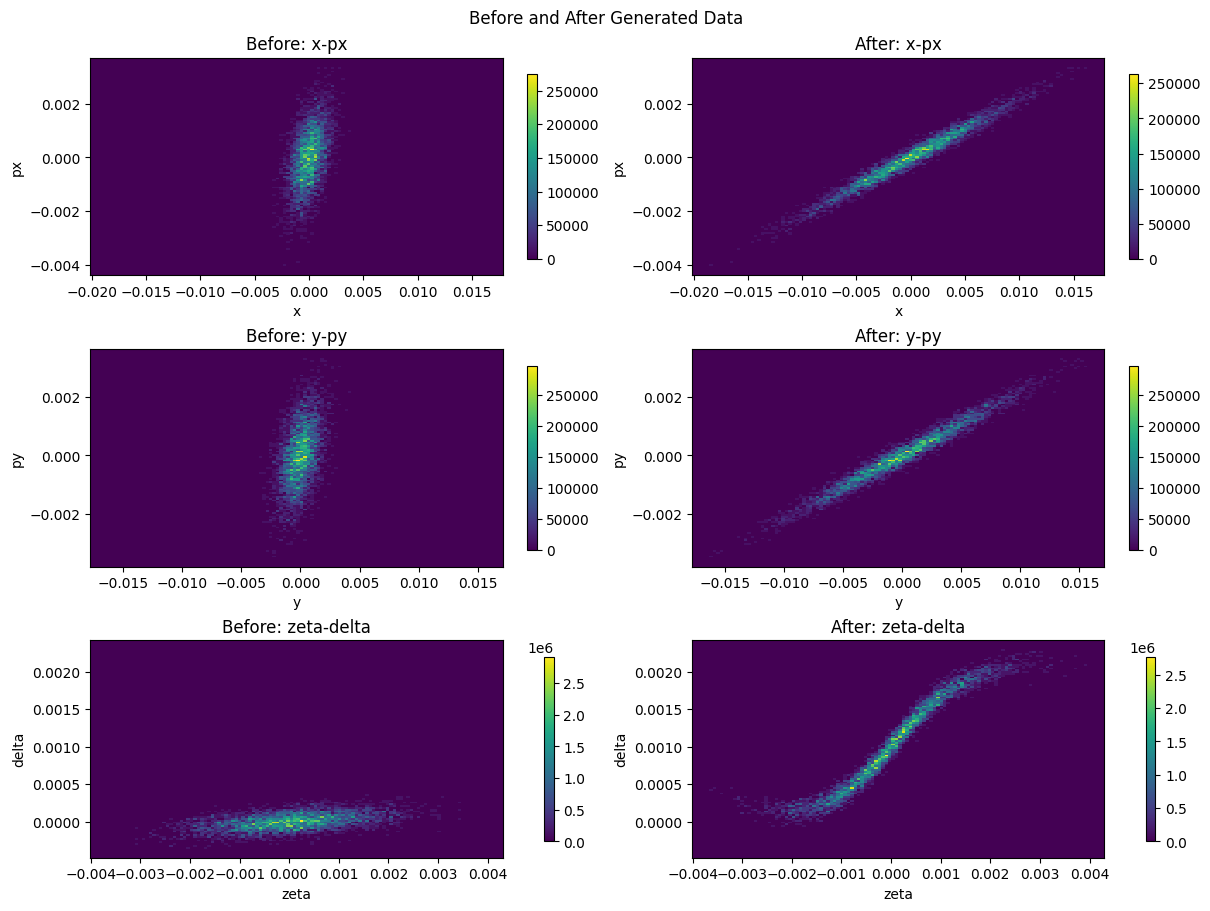

In [10]:
import matplotlib.pyplot as plt

def plot_example_distributions(i: int = 0, bins: int = 100, figsize: tuple = (12, 9),cmap = "viridis", title: str = "Before and After Generated Data") -> None:
    """
    Plot before/after 2D marginal histograms for the i-th example:
      - Row 1: x/px before (left) and after (right)
      - Row 2: y/py before (left) and after (right)
      - Row 3: zeta/delta before (left) and after (right)

    Expects data dict with keys "X_cloud" and "Y_cloud" present in the notebook.
    """
    if "X_cloud" not in data or "Y_cloud" not in data:
        raise RuntimeError("data must contain 'X_cloud' and 'Y_cloud' arrays")

    X = data["X_cloud"]  # shape (n_samples, n_particles, 6)
    Y = data["Y_cloud"]

    n_samples = X.shape[0]
    if not (0 <= i < n_samples):
        raise IndexError(f"i out of range (0 <= i < {n_samples})")

    z_before = X[i].astype(np.float64)  # (n_particles, 6)
    z_after = Y[i].astype(np.float64)

    projections = [
        (0, 3, "x", "px"),
        (1, 4, "y", "py"),
        (2, 5, "zeta", "delta"),
    ]

    fig, axes = plt.subplots(3, 2, figsize=figsize, constrained_layout=True)

    for row, (i, j, xl, yl) in enumerate(projections):
        all2 = np.vstack([z_before[:, [i, j]], z_after[:, [i, j]]])
        xpad = 0.05 * (all2[:, 0].max() - all2[:, 0].min() + 1e-15)
        ypad = 0.05 * (all2[:, 1].max() - all2[:, 1].min() + 1e-15)
        ranges = [
            [all2[:, 0].min() - xpad, all2[:, 0].max() + xpad],
            [all2[:, 1].min() - ypad, all2[:, 1].max() + ypad],
        ]

        im0 = axes[row, 0].hist2d(
            z_before[:, i], z_before[:, j],
            bins=bins, range=ranges, density=True, cmap=cmap
        )[3]
        fig.colorbar(im0, ax=axes[row, 0], shrink=0.85)
        axes[row, 0].set_title(f"Before: {xl}-{yl}")
        axes[row, 0].set_xlabel(xl)
        axes[row, 0].set_ylabel(yl)

        im1 = axes[row, 1].hist2d(
            z_after[:, i], z_after[:, j],
            bins=bins, range=ranges, density=True, cmap=cmap
        )[3]
        fig.colorbar(im1, ax=axes[row, 1], shrink=0.85)
        axes[row, 1].set_title(f"After: {xl}-{yl}")
        axes[row, 1].set_xlabel(xl)
        axes[row, 1].set_ylabel(yl)

    fig.suptitle(title)
    plt.show()



idx_random = np.random.randint(512)
plot_example_distributions(i=idx_random, bins=120)

In [11]:
from torch.utils.data import Dataset, DataLoader

class CloudDataset(Dataset):
    """
    Expects data dict with:
      X_cloud: [Ns, Np, 6]
      Y_cloud: [Ns, Np, 6]
      MU:      [Ns, m]
    Optionally can use split indices train/val/test in the npz.
    """
    def __init__(self, data: dict, split: str = "train"):
        self.X = data["X_cloud"]
        self.Y = data["Y_cloud"]
        self.MU = data["MU"]

        if split in data:
            self.idx = data[split].astype(np.int64)
        else:
            self.idx = np.arange(self.X.shape[0], dtype=np.int64)

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i: int):
        j = int(self.idx[i])
        X = torch.from_numpy(self.X[j]).float()   # [Np,6]
        Y = torch.from_numpy(self.Y[j]).float()   # [Np,6]
        MU = torch.from_numpy(self.MU[j]).float() # [m]
        return X, Y, MU

def make_dummy_lattice_tokens(B: int, N: int, device: str):
    """
    Creates a simple placeholder lattice:
      - all elements are "drifts" with length=1.0
      - everything else 0
    elem_params: [B,N,7] = [L,K1,K2,phi,Vrf,frf,phirf]
    elem_s:      [B,N]   cumulative s at entrance
    """
    elem_params = torch.zeros(B, N, 7, device=device, dtype=torch.float32)
    elem_params[..., 0] = 1.0  # L=1m
    elem_s = torch.cumsum(elem_params[..., 0], dim=1) - elem_params[..., 0]
    return elem_params, elem_s


In [12]:
MU_spec = [
    1e-9,       # Q_bunch in Coulombs -> scale to nC
    1e-3,       # pipe_radius in meters -> scale to mm
    {"unit": 1.0, "op": "log"}  # impedance_scale -> log1p
]

In [19]:

print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():import torch

print("PyTorch:", torch.__version__)
print("CUDA runtime:", torch.version.cuda)
print("Arch list:", torch.cuda.get_arch_list())
print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
GPU count: 1
PyTorch: 2.10.0+cu128
CUDA runtime: 12.8
Arch list: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']
GPU name: NVIDIA H100 NVL


In [20]:
data = load_npz(path)

print("keys:", sorted(data.keys()))
print("X_cloud:", data["X_cloud"].shape, data["X_cloud"].dtype)
print("Y_cloud:", data["Y_cloud"].shape, data["Y_cloud"].dtype)
print("MU:", data["MU"].shape, data["MU"].dtype)

device = "cuda" if torch.cuda.is_available() else "cpu"

train_ds = CloudDataset(data, split="train" if "train" in data else "train")
val_ds   = CloudDataset(data, split="val" if "val" in data else "val")

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=0, drop_last=False)

mu_dim = int(data["MU"].shape[-1])
model = BeamLatentTrackingModel(mu_dim=mu_dim, latent_dim=256, d_model=512).to(device)

opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)

N_elem = 32  # paper uses N=32; choose any fixed number for dummy run

def run_eval():
    model.eval()
    losses = []
    with torch.no_grad():
        for X, Y, MU in val_loader:
            X = X.to(device)
            Y = Y.to(device)
            MU = MU.to(device)
            B = X.shape[0]
            elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)
            out = model(X, MU, elem_params, elem_s, mode="AR")
            ld = compute_total_loss(out, Y)
            losses.append(ld["loss"].item())
    return float(np.mean(losses)) if losses else float("nan")

# training loop
model.train()
for epoch in range(100):
    model.train()
    for step, (X, Y, MU) in enumerate(train_loader):
        X = X.to(device)
        Y = Y.to(device)
        MU = MU.to(device)
        MU_enc = mu_prep(MU)

        B = X.shape[0]
        elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)

        opt.zero_grad(set_to_none=True)
        out = model(X, MU_enc, elem_params, elem_s, mode="AR")
        ld = compute_total_loss(out, Y)
        ld["loss"].backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if step % 20 == 0:
            print(f"epoch={epoch} step={step} loss={ld['loss'].item():.6f} reconN={ld['reconN'].item():.6f} kl={ld['kl'].item():.6f}")

    val_loss = run_eval()
    print(f"[epoch {epoch}] val_loss={val_loss:.6f}")

keys: ['MU', 'X_cloud', 'X_lambda', 'Y_cloud', 'Y_lambda', 'centroid_in', 'centroid_out', 'cov_in', 'cov_out', 'family_id', 'test', 'train', 'val', 'zeta_grid']
X_cloud: (512, 4096, 6) float32
Y_cloud: (512, 4096, 6) float32
MU: (512, 3) float32


/tmp/ipykernel_1197390/1581004197.py:27: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [ ]:
PHASE_SPACE_LABELS = ("x", "y", "zeta", "px", "py", "delta")

# same PAIR_INDEX order as in the model file
PAIR_INDEX = [
    (0, 1), (0, 2), (0, 3), (0, 4), (0, 5),
    (1, 2), (1, 3), (1, 4), (1, 5),
    (2, 3), (2, 4), (2, 5),
    (3, 4), (3, 5),
    (4, 5),
]

def plot_sigma_centroid_scatter(sigma_true, sigma_pred, cent_true, cent_pred, title_prefix=""):
    # sigma_*: [B,6], cent_*: [B,6]
    fig, axes = plt.subplots(2, 6, figsize=(18, 6), constrained_layout=True)

    # sigmas
    for d in range(6):
        ax = axes[0, d]
        x = sigma_true[:, d]
        y = sigma_pred[:, d]
        ax.scatter(x, y, s=8, alpha=0.6)
        lo = min(x.min(), y.min())
        hi = max(x.max(), y.max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
        ax.set_title(f"{title_prefix} sigma({PHASE_SPACE_LABELS[d]})")
        ax.set_xlabel("truth")
        ax.set_ylabel("pred")
        ax.grid(alpha=0.2)

    # centroids
    for d in range(6):
        ax = axes[1, d]
        x = cent_true[:, d]
        y = cent_pred[:, d]
        ax.scatter(x, y, s=8, alpha=0.6)
        lo = min(x.min(), y.min())
        hi = max(x.max(), y.max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
        ax.set_title(f"{title_prefix} <{PHASE_SPACE_LABELS[d]}>")
        ax.set_xlabel("truth")
        ax.set_ylabel("pred")
        ax.grid(alpha=0.2)

    return fig

def plot_hist_triplet(truth_map, pred_map, title="", vmax=None):
    """
    truth_map, pred_map: [64,64] arrays
    Shows truth / pred / diff (pred-truth)
    """
    diff = pred_map - truth_map
    vmax = vmax if vmax is not None else float(max(truth_map.max(), pred_map.max()) + 1e-12)
    dv = float(np.max(np.abs(diff)) + 1e-12)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)
    im0 = axes[0].imshow(truth_map, origin="lower", aspect="auto", vmin=0.0, vmax=vmax)
    axes[0].set_title("Truth")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(pred_map, origin="lower", aspect="auto", vmin=0.0, vmax=vmax)
    axes[1].set_title("Pred")
Submitted VAE eval job: 46007865
Loaded VAE: missing
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    im2 = axes[2].imshow(diff, origin="lower", aspect="auto", vmin=-dv, vmax=dv, cmap="RdBu_r")
    axes[2].set_title("Pred - Truth")
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    fig.suptitle(title)
    return fig


The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.


In [ ]:
model.eval()
X, Y, MU = next(iter(val_loader))

X = X.to(device)
Y = Y.to(device)
MU = MU.to(device)

B = X.shape[0]
elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)

with torch.no_grad():
    out = model(X, MU, elem_params, elem_s, mode="AR")

# truth stats from Y_cloud
cent_true_t, sig_true_t = beam_centroid_sigma(Y)  # centroid, sigma
sig_pred_t = out["sigmaN_hat"]
cent_pred_t = out["centroidN_hat"]

# move to numpy
sig_true = sig_true_t.detach().cpu().numpy()
sig_pred = sig_pred_t.detach().cpu().numpy()
cent_true = cent_true_t.detach().cpu().numpy()
cent_pred = cent_pred_t.detach().cpu().numpy()

# scatter plots
plot_sigma_centroid_scatter(sig_true, sig_pred, cent_true, cent_pred, title_prefix="Final")
plt.show()


NameError: name 'model' is not defined

In [14]:
y_hist = cloud_to_pairwise_hists(Y, nbins=64).detach().cpu().numpy()      # [B,15,64,64]
y_hat = out["xN_hat"].detach().cpu().numpy()                             # [B,15,64,64]

sample_idx = 3
pairs_to_plot = [0, 1, 10]  # choose which of the 15 maps you want (indices into PAIR_INDEX)

for pidx in pairs_to_plot:
    i, j = PAIR_INDEX[pidx]
    title = f"Sample {sample_idx} pair ({PHASE_SPACE_LABELS[i]}, {PHASE_SPACE_LABELS[j]})"
    truth_map = y_hist[sample_idx, pidx]
    pred_map = y_hat[sample_idx, pidx]
    plot_hist_triplet(truth_map, pred_map, title=title)
    plt.show()

NameError: name 'Y' is not defined

truth: min=0.000e+00 max=9.033e-03 mean=2.441e-04 sum=1.000e+00
pred: min=0.000e+00 max=5.070e-03 mean=2.441e-04 sum=1.000e+00


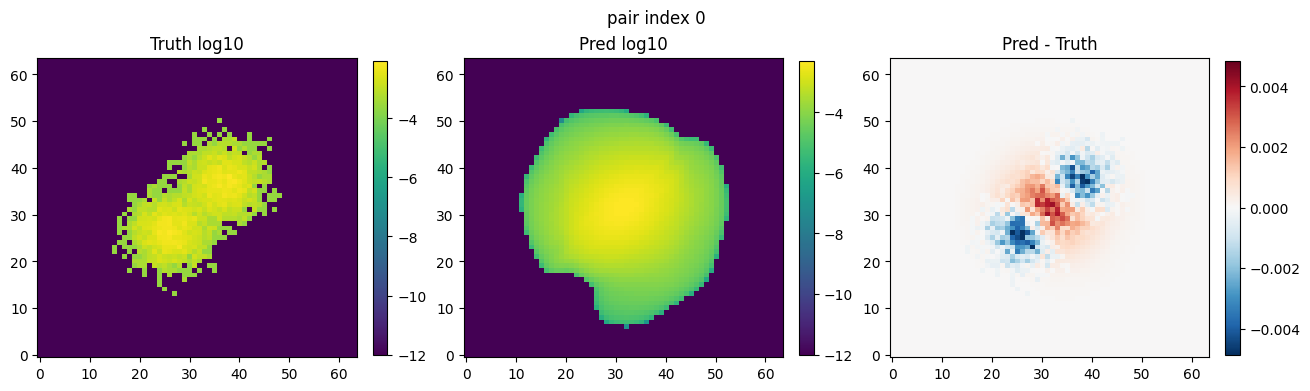

In [68]:
import numpy as np
import matplotlib.pyplot as plt

def describe_map(a, name="map"):
    a = np.asarray(a)
    print(f"{name}: min={a.min():.3e} max={a.max():.3e} mean={a.mean():.3e} sum={a.sum():.3e}")

def plot_triplet_log(truth, pred, title=""):
    truth = np.asarray(truth)
    pred  = np.asarray(pred)
    diff  = pred - truth

    # Use truth-based vmax so you can see structure
    vmax = float(np.percentile(truth, 99.9) + 1e-12)
    vmax = max(vmax, float(truth.max()) + 1e-12)

    # log images: log10(x + eps)
    eps = 1e-12
    tlog = np.log10(truth + eps)
    plog = np.log10(pred  + eps)

    # diff uses symmetric linear scale
    dv = float(np.percentile(np.abs(diff), 99.9) + 1e-12)

    fig, ax = plt.subplots(1, 3, figsize=(13, 3.8), constrained_layout=True)

    im0 = ax[0].imshow(tlog, origin="lower", aspect="auto")
    ax[0].set_title("Truth log10")
    plt.colorbar(im0, ax=ax[0], fraction=0.046)

    im1 = ax[1].imshow(plog, origin="lower", aspect="auto")
    ax[1].set_title("Pred log10")
    plt.colorbar(im1, ax=ax[1], fraction=0.046)

    im2 = ax[2].imshow(diff, origin="lower", aspect="auto", cmap="RdBu_r", vmin=-dv, vmax=dv)
    ax[2].set_title("Pred - Truth")
    plt.colorbar(im2, ax=ax[2], fraction=0.046)

    fig.suptitle(title)
    plt.show()

# --- run on ONE sample from val ---
model.eval()
X, Y, MU = next(iter(val_loader))
X, Y, MU = X.to(device), Y.to(device), MU.to(device)
B = X.shape[0]
elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)

with torch.no_grad():
    out = model(X, MU, elem_params, elem_s, mode="AR")

y_hist = cloud_to_pairwise_hists(Y, nbins=64).detach().cpu().numpy()
y_hat  = out["xN_hat"].detach().cpu().numpy()

sample_idx = 0
pidx = 0  # pick a pair map
truth_map = y_hist[sample_idx, pidx]
pred_map  = y_hat[sample_idx, pidx]

describe_map(truth_map, "truth")
describe_map(pred_map,  "pred")

plot_triplet_log(truth_map, pred_map, title=f"pair index {pidx}")

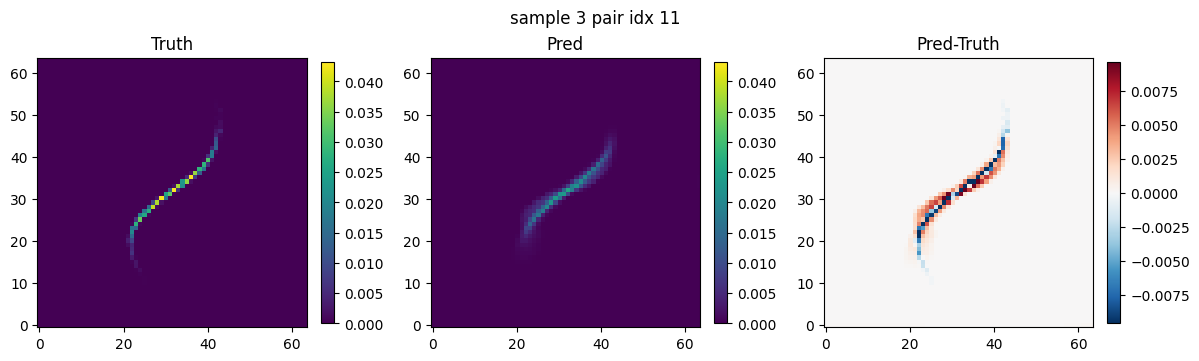

In [79]:
import matplotlib.pyplot as plt
import numpy as np

def show_triplet(truth, pred, title=""):
    truth = np.asarray(truth)
    pred  = np.asarray(pred)
    diff  = pred - truth

    # scale so structure is visible
    vmax = float(np.percentile(truth, 99.5) + 1e-12)
    vmax = max(vmax, float(truth.max()) + 1e-12)
    dv   = float(np.percentile(np.abs(diff), 99.5) + 1e-12)

    fig, ax = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)
    im0 = ax[0].imshow(truth, origin="lower", vmin=0.0, vmax=vmax)
    ax[0].set_title("Truth"); plt.colorbar(im0, ax=ax[0], fraction=0.046)

    im1 = ax[1].imshow(pred, origin="lower", vmin=0.0, vmax=vmax)
    ax[1].set_title("Pred"); plt.colorbar(im1, ax=ax[1], fraction=0.046)

    im2 = ax[2].imshow(diff, origin="lower", cmap="RdBu_r", vmin=-dv, vmax=dv)
    ax[2].set_title("Pred-Truth"); plt.colorbar(im2, ax=ax[2], fraction=0.046)

    fig.suptitle(title)
    plt.show()

# compute prediction
B = X.shape[0]
elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)
with torch.no_grad():
    out = model(X, MU, elem_params, elem_s, mode="AR")
y_pred = out["xN_hat"].detach().cpu().numpy()

b = 3
pidx = 11
show_triplet(y_hist[b, pidx], y_pred[b, pidx], title=f"sample {b} pair idx {pidx}")

In [51]:
with torch.no_grad():
    out = model(X, MU, elem_params, elem_s, mode="AR")

pred = out["xN_hat"]
print("pred min/max/mean:", pred.min().item(), pred.max().item(), pred.mean().item())
print("any NaN:", torch.isnan(pred).any().item())
y_true = cloud_to_pairwise_hists(Y, nbins=64)
print("truth min/max/mean:", y_true.min().item(), y_true.max().item(), y_true.mean().item())
print("truth sum per map (mean):", y_true.sum(dim=(-1,-2)).mean().item())

pred = out["xN_hat"]
print("pred sum per map (mean):", pred.sum(dim=(-1,-2)).mean().item())

pred min/max/mean: 0.0 0.022511130198836327 0.000244140625
any NaN: False
truth min/max/mean: 0.0 0.04638671875 0.000244140625
truth sum per map (mean): 1.0
pred sum per map (mean): 1.0


In [52]:
model.eval()
X, Y, MU = next(iter(val_loader))
X, Y, MU = X.to(device), Y.to(device), MU.to(device)
B = X.shape[0]
elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)

with torch.no_grad():
    out = model(X, MU, elem_params, elem_s, mode="AR")

pred = out["xN_hat"]
truth = cloud_to_pairwise_hists(Y, nbins=64)

print("pred  min/max/mean:", pred.min().item(), pred.max().item(), pred.mean().item())
print("truth min/max/mean:", truth.min().item(), truth.max().item(), truth.mean().item())
print("pred  sum per map (mean):", pred.sum(dim=(-1,-2)).mean().item())
print("truth sum per map (mean):", truth.sum(dim=(-1,-2)).mean().item())

pred  min/max/mean: 0.0 0.02223901078104973 0.000244140625
truth min/max/mean: 0.0 0.04638671875 0.000244140625
pred  sum per map (mean): 1.0
truth sum per map (mean): 1.0
